<a href="https://colab.research.google.com/github/Biaya10/Biaya10/blob/main/LogiExpressBogota.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- SISTEMA LOGIEXPRESS (BOGOTÁ COMPLETE) ---
1. Calcular ruta más corta (Origen -> Destino)
2. Calcular ruta para múltiples entregas
3. Visualizar mapa completo de Bogotá
4. Ver lista de localidades
5. Salir
Seleccione una opción: 1

Localidades disponibles: Antonio Nariño, Barrios Unidos, Bosa, Chapinero, Ciudad Bolívar, Engativá, Fontibón, Kennedy, La Candelaria, Los Mártires, Puente Aranda, Rafael Uribe Uribe, San Cristóbal, Santa Fe, Suba, Sumapaz, Teusaquillo, Tunjuelito, Usaquén, Usme
Ingrese localidad de origen: Barrios Unidos
Ingrese localidad de destino: Los Mártires

 RECOMENDACIÓN PARA EL REPARTIDOR:
La ruta más rápida es: Barrios Unidos ➔ Teusaquillo ➔ Los Mártires
Tiempo estimado: 27 minutos


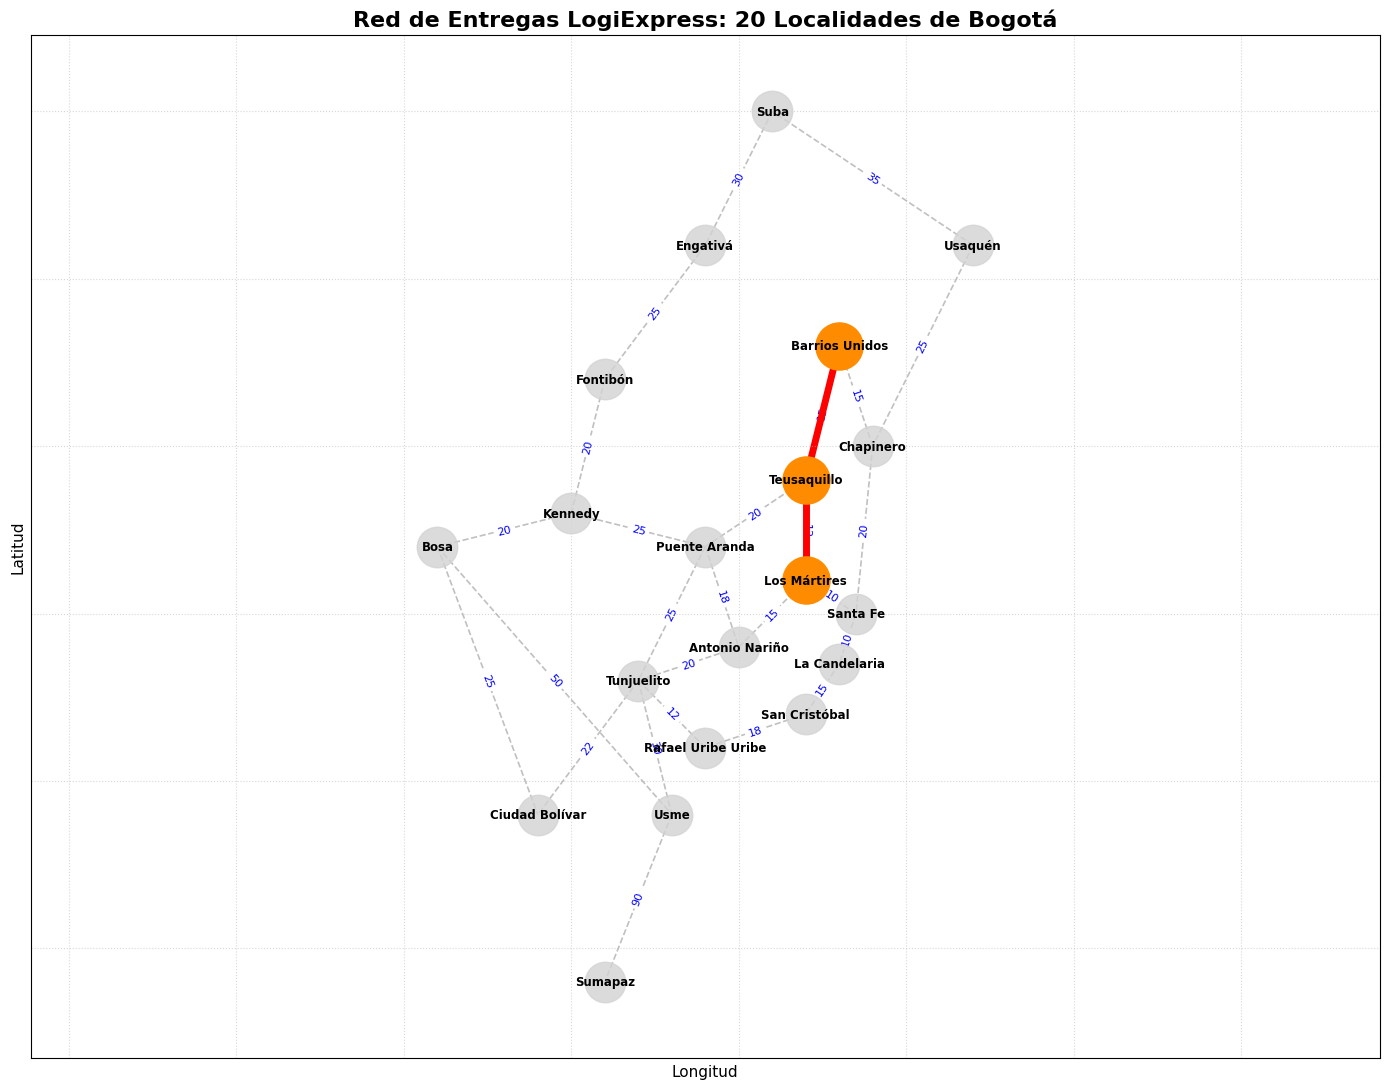


--- SISTEMA LOGIEXPRESS (BOGOTÁ COMPLETE) ---
1. Calcular ruta más corta (Origen -> Destino)
2. Calcular ruta para múltiples entregas
3. Visualizar mapa completo de Bogotá
4. Ver lista de localidades
5. Salir


KeyboardInterrupt: Interrupted by user

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import heapq

# COORDENADAS AJUSTADAS VISUALMENTE: Se acercaron Usme y Sumapaz al norte
# para que Matplotlib haga zoom automático y el mapa no se vea pequeño.
COORDENADAS_BOGOTA = {
    'Usaquén': (4.71, -74.03),
    'Chapinero': (4.65, -74.06),
    'Santa Fe': (4.60, -74.065),
    'La Candelaria': (4.585, -74.07),
    'San Cristóbal': (4.57, -74.08),
    'Usme': (4.54, -74.12),
    'Tunjuelito': (4.58, -74.13),
    'Bosa': (4.62, -74.19),
    'Kennedy': (4.63, -74.15),
    'Fontibón': (4.67, -74.14),
    'Engativá': (4.71, -74.11),
    'Suba': (4.75, -74.09),
    'Barrios Unidos': (4.68, -74.07),
    'Teusaquillo': (4.64, -74.08),
    'Los Mártires': (4.61, -74.08),
    'Antonio Nariño': (4.59, -74.10),
    'Puente Aranda': (4.62, -74.11),
    'Rafael Uribe Uribe': (4.56, -74.11),
    'Ciudad Bolívar': (4.54, -74.16),
    'Sumapaz': (4.49, -74.14)
}

# Lista de rutas logísticas interconectadas (pesos en minutos).
RUTAS_LOGISTICAS_BOGOTA = [
    ('Usaquén', 'Suba', 35),
    ('Usaquén', 'Chapinero', 25),
    ('Suba', 'Engativá', 30),
    ('Engativá', 'Fontibón', 25),
    ('Fontibón', 'Kennedy', 20),
    ('Kennedy', 'Bosa', 20),
    ('Chapinero', 'Barrios Unidos', 15),
    ('Barrios Unidos', 'Teusaquillo', 15),
    ('Teusaquillo', 'Puente Aranda', 20),
    ('Puente Aranda', 'Kennedy', 25),
    ('Chapinero', 'Santa Fe', 20),
    ('Santa Fe', 'La Candelaria', 10),
    ('La Candelaria', 'San Cristóbal', 15),
    ('Puente Aranda', 'Tunjuelito', 25),
    ('Tunjuelito', 'Usme', 30),
    ('Bosa', 'Usme', 50),
    ('Teusaquillo', 'Los Mártires', 12),
    ('Los Mártires', 'Santa Fe', 10),
    ('Los Mártires', 'Antonio Nariño', 15),
    ('Antonio Nariño', 'Puente Aranda', 18),
    ('Antonio Nariño', 'Tunjuelito', 20),
    ('San Cristóbal', 'Rafael Uribe Uribe', 18),
    ('Tunjuelito', 'Rafael Uribe Uribe', 12),
    ('Tunjuelito', 'Ciudad Bolívar', 22),
    ('Bosa', 'Ciudad Bolívar', 25),
    ('Usme', 'Sumapaz', 90)
]
# Clase principal que encapsula la lógica matemática y la representación gráfica
#de la red de distribución postal para las 20 localidades de Bogotá.
class LogiExpressBogota:

    #Método constructor de la clase. Inicializa las estructuras base en memoria.
    def __init__(self):
        self.grafo = {}
        self.G = nx.Graph()

    #Método que toma la base de datos externa (lista de tuplas viales) y mapea
    #las localidades y tiempos dentro de las estructuras internas de la clase.
    def inicializar_red(self, rutas_list):

        for u, v, tiempo in rutas_list:
            if u not in self.grafo:
                self.grafo[u] = {}
            if v not in self.grafo:
                self.grafo[v] = {}
            self.grafo[u][v] = tiempo
            self.grafo[v][u] = tiempo
            self.G.add_edge(u, v, weight=tiempo)

    # Este método aplica el algoritmo de Dijkstra para encontrar
    # las rutas más cortas desde una localidad origen hacia todas las demás.
    def dijkstra(self, origen):

        # Se crea un diccionario donde todas las distancias
        # comienzan en infinito.
        distancias = {nodo: float('infinity') for nodo in self.grafo}

        # La distancia del origen es 0 porque iniciamos allí.
        distancias[origen] = 0

        # Aquí se guarda el nodo anterior de cada ruta,
        # esto sirve después para reconstruir el camino.
        predecesores = {nodo: None for nodo in self.grafo}

        # Cola de prioridad usada por Dijkstra.
        prioridad = [(0, origen)]

        # Mientras existan nodos por revisar:
        while prioridad:

            # Se extrae el nodo con menor distancia acumulada.
            distancia_actual, nodo_actual = heapq.heappop(prioridad)

            # Si ya existe una mejor distancia, se ignora.
            if distancia_actual > distancias[nodo_actual]:
                continue

            # Se recorren los vecinos del nodo actual.
            for vecino, peso in self.grafo[nodo_actual].items():

                # Se calcula la nueva distancia.
                distancia = distancia_actual + peso

                # Si encontramos un camino más corto:
                if distancia < distancias[vecino]:

                    # Actualizamos la distancia mínima.
                    distancias[vecino] = distancia

                    # Guardamos desde qué nodo llegamos.
                    predecesores[vecino] = nodo_actual

                    # Agregamos el vecino a la cola de prioridad.
                    heapq.heappush(prioridad, (distancia, vecino))

        # Retorna las distancias mínimas y los predecesores.
        return distancias, predecesores

    # Este método obtiene la ruta exacta entre un origen y un destino.
    def obtener_ruta(self, origen, destino):

        # Se ejecuta Dijkstra para calcular distancias mínimas.
        distancias, predecesores = self.dijkstra(origen)

        # Lista donde se almacenará la ruta final.
        ruta = []

        # Empezamos desde el destino.
        actual = destino

        # Si el destino no tiene conexión, retorna infinito.
        if distancias.get(destino, float('infinity')) == float('infinity'):
            return None, float('infinity')

        # Reconstruimos la ruta desde el destino hasta el origen.
        while actual is not None:

            # Insertamos cada nodo al inicio de la lista.
            ruta.insert(0, actual)

            # Avanzamos al nodo anterior.
            actual = predecesores[actual]

        # Retorna la ruta y el tiempo total.
        return ruta, distancias[destino]

    # Este método calcula una ruta para visitar varios destinos.
    def ruta_multiples_destinos(self, origen, destinos):

        # La ruta inicia desde el origen.
        ruta_total = [origen]

        # Tiempo total acumulado.
        tiempo_total = 0

        # Posición actual del repartidor.
        actual = origen

        # Copia de los destinos pendientes.
        pendientes = destinos.copy()

        # Mientras existan destinos por visitar:
        while pendientes:

            # Variables para guardar la mejor opción encontrada.
            mejor_destino = None
            mejor_camino = None
            mejor_tiempo = float('infinity')

            # Se revisa cada destino pendiente.
            for destino in pendientes:

                # Se calcula la mejor ruta hacia ese destino.
                camino, tiempo = self.obtener_ruta(actual, destino)

                # Si el camino existe y es el más corto:
                if camino and tiempo < mejor_tiempo:

                    # Se actualiza la mejor opción.
                    mejor_destino = destino
                    mejor_camino = camino
                    mejor_tiempo = tiempo

            # Si no existe ningún destino alcanzable:
            if mejor_destino is None:
                return None, float('infinity')

            # Se agrega el mejor camino a la ruta total.
            ruta_total.extend(mejor_camino[1:])

            # Se suma el tiempo recorrido.
            tiempo_total += mejor_tiempo

            # El repartidor ahora se encuentra en el mejor destino.
            actual = mejor_destino

            # Se elimina el destino ya visitado.
            pendientes.remove(mejor_destino)

        # Retorna la ruta completa y el tiempo total.
        return ruta_total, tiempo_total

    def visualizar_sistema(self, ruta_resaltada=None):
        # Crea una nueva figura para el gráfico con un tamaño específico.
        plt.figure(figsize=(14, 11))
        # Mapea las localidades del grafo a sus coordenadas para el dibujo.
        pos = {loc: (long, lat) for loc, (lat, long) in COORDENADAS_BOGOTA.items() if loc in self.grafo}

        # Dibuja los nodos (localidades) del grafo.
        nx.draw_networkx_nodes(self.G, pos, node_size=850, node_color='lightgray', alpha=0.8)
        # Dibuja los bordes (rutas) del grafo.
        nx.draw_networkx_edges(self.G, pos, edge_color='silver', width=1.2, style='dashed')
        # Dibuja las etiquetas de los nodos (nombres de las localidades).
        nx.draw_networkx_labels(self.G, pos, font_size=8.5, font_weight='bold')

        # Obtiene los pesos (tiempos) de los bordes para mostrarlos como etiquetas.
        edge_labels = nx.get_edge_attributes(self.G, 'weight')
        # Dibuja las etiquetas de los bordes.
        nx.draw_networkx_edge_labels(self.G, pos, edge_labels=edge_labels, font_size=8, font_color='blue')

        # Si se proporciona una ruta para resaltar, la dibuja.
        if ruta_resaltada:
            # Resalta los nodos de la ruta con un color y tamaño diferente.
            nx.draw_networkx_nodes(self.G, pos, nodelist=ruta_resaltada, node_color='#FF8C00', node_size=1150)
            # Crea una lista de tuplas para representar los bordes de la ruta.
            path_edges = list(zip(ruta_resaltada, ruta_resaltada[1:]))
            # Dibuja los bordes de la ruta con un color y grosor diferente.
            nx.draw_networkx_edges(self.G, pos, edgelist=path_edges, edge_color='red', width=5)

        # Añade un título al gráfico.
        plt.title("Red de Entregas LogiExpress: 20 Localidades de Bogotá", fontsize=16, fontweight='bold')
        # Añade etiquetas a los ejes X e Y.
        plt.xlabel("Longitud", fontsize=11)
        plt.ylabel("Latitud", fontsize=11)
        # Añade una cuadrícula al gráfico.
        plt.grid(True, linestyle=':', alpha=0.5)
        # Asegura que las proporciones de los ejes sean iguales para evitar distorsiones.
        plt.axis('equal')

        # Ajusta automáticamente los parámetros de la subtrama para un ajuste ceñido.
        plt.tight_layout()
        # Muestra el gráfico.
        plt.show()

def menu_bogota():
    # Crea una instancia de la clase LogiExpressBogota.
    logistica = LogiExpressBogota()
    # Inicializa la red de rutas con los datos predefinidos de Bogotá.
    logistica.inicializar_red(RUTAS_LOGISTICAS_BOGOTA)
    # Obtiene una lista ordenada de todas las localidades disponibles en el grafo.
    localidades_disponibles = sorted(list(logistica.grafo.keys()))

    # Bucle principal del menú para interactuar con el usuario.
    while True:
        # Muestra las opciones del menú al usuario.
        print("\n--- SISTEMA LOGIEXPRESS (BOGOTÁ COMPLETE) ---")
        print("1. Calcular ruta más corta (Origen -> Destino)")
        print("2. Calcular ruta para múltiples entregas")
        print("3. Visualizar mapa completo de Bogotá")
        print("4. Ver lista de localidades")
        print("5. Salir")

        # Solicita al usuario que seleccione una opción.
        opcion = input("Seleccione una opción: ").strip()

        # Opción 1: Calcular ruta más corta entre un origen y un destino.
        if opcion == '1':
            print("\nLocalidades disponibles:", ", ".join(localidades_disponibles))
            inicio = input("Ingrese localidad de origen: ").strip().title()
            fin = input("Ingrese localidad de destino: ").strip().title()

            # Verifica que las localidades ingresadas existan en el grafo.
            if inicio in logistica.grafo and fin in logistica.grafo:
                # Obtiene la ruta y el tiempo estimado usando Dijkstra.
                camino, tiempo = logistica.obtener_ruta(inicio, fin)
                if camino:
                    # Muestra la ruta recomendada y el tiempo estimado.
                    print("\n RECOMENDACIÓN PARA EL REPARTIDOR:")
                    print(f"La ruta más rápida es: {' ➔ '.join(camino)}")
                    print(f"Tiempo estimado: {tiempo} minutos")
                    # Visualiza la ruta resaltada en el mapa.
                    logistica.visualizar_sistema(ruta_resaltada=camino)
                else:
                    # Mensaje si no se encuentra una ruta.
                    print(f"No se encontró una ruta transitable entre {inicio} y {fin}.")
            else:
                # Mensaje si las localidades no son válidas.
                print("Una o ambas localidades no existen o están mal escritas.")

        # Opción 2: Calcular ruta para múltiples entregas.
        elif opcion == '2':
            try:
                print("\nLocalidades disponibles:", ", ".join(localidades_disponibles))
                origen_repartidor = input("Ingrese la localidad inicial del repartidor: ").strip().title()

                # Verifica que la localidad de origen del repartidor exista.
                if origen_repartidor not in logistica.grafo:
                    print("La localidad inicial no existe o está mal escrita.")
                    continue

                # Solicita el número de destinos a visitar.
                num_destinos = int(input("¿Cuántos destinos necesita visitar?: "))
                if num_destinos <= 0:
                    print("El número de destinos debe ser mayor que cero.")
                    continue

                # Recopila los destinos, verificando su existencia.
                destinos = []
                for i in range(num_destinos):
                    destino = input(f"Ingrese destino #{i + 1}: ").strip().title()
                    if destino in logistica.grafo:
                        destinos.append(destino)
                    else:
                        print(f"La localidad '{destino}' no existe. No será agregada.")

                # Si no hay destinos válidos, informa al usuario.
                if not destinos:
                    print("No se ingresaron destinos válidos.")
                    continue

                # Calcula la ruta óptima para múltiples destinos.
                ruta_total, tiempo_total = logistica.ruta_multiples_destinos(origen_repartidor, destinos)
                if ruta_total:
                    # Muestra la ruta sugerida y el tiempo total.
                    print("\n RUTA SUGERIDA PARA MÚLTIPLES ENTREGAS:")
                    print(" ➔ ".join(ruta_total))
                    print(f" Tiempo total estimado: {tiempo_total} minutos")
                    # Visualiza la ruta completa en el mapa.
                    logistica.visualizar_sistema(ruta_resaltada=ruta_total)
                else:
                    # Mensaje si no se pudo calcular la ruta.
                    print(" No se pudo calcular una ruta para los destinos ingresados.")
            except ValueError:
                # Manejo de error para entradas no numéricas.
                print("Por favor, ingrese un número válido.")

        # Opción 3: Visualizar el mapa completo de Bogotá.
        elif opcion == '3':
            print("\nMostrando mapa completo del sistema LogiExpress...")
            logistica.visualizar_sistema()

        # Opción 4: Mostrar la lista de localidades disponibles.
        elif opcion == '4':
            print("\n--- 20 LOCALIDADES DE BOGOTÁ DISPONIBLES ---")
            print(", ".join(localidades_disponibles))

        # Opción 5: Salir del programa.
        elif opcion == '5':
            print("Saliendo del sistema. ¡Hasta pronto!")
            break
        # Opción no válida.
        else:
            print("Opción no válida. Por favor, intente de nuevo.")

# Punto de entrada principal del script.
if __name__ == '__main__':
    menu_bogota()
